# Category: Health and Quality of Life 
We will conduct our exploratory data analysis for this category using selected variables. Then we will create a scoring system using PCA. Finally, we will validate our results using real migration data.

# Setup

In [1]:
import os
import sys
import math
import json
from typing import List, Dict, Optional, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("health_and_quality_of_life.csv")

In [3]:
df

,FIPS,State,County,access to exercise opportunities raw value2014,access to exercise opportunities raw value2015,access to exercise opportunities raw value2016,access to exercise opportunities raw value2017,access to exercise opportunities raw value2018,access to exercise opportunities raw value2019,access to exercise opportunities raw value2020,...,primary care physicians raw value2018,primary care physicians raw value2019,primary care physicians raw value2020,primary care physicians raw value2021,primary care physicians raw value2022,primary care physicians raw value2023,primary care physicians raw value2024,primary care physicians raw value2025,Longitude,Latitude
0,0,USA,USA,0.769568,0.846571,0.839211,0.839211,0.830934,0.838945,0.841687,...,0.000755,0.000754,0.000755,0.000758,0.000765,0.000764,0.000749,0.000749,NaN,NaN
1,1000,NaN,NaN,0.517159,0.641050,0.628067,0.628067,0.628190,0.616496,0.611123,...,0.000652,0.000654,0.000648,0.000652,0.000658,0.000658,0.000637,0.000637,NaN,NaN
2,1001,AL,Autauga,0.592989,0.736838,0.708215,0.708215,0.711202,0.686775,0.691301,...,0.000452,0.000415,0.000450,0.000468,0.000447,0.000445,0.000440,0.000440,-86.642900,32.535142
3,1003,AL,Baldwin,0.580227,0.736181,0.721685,0.721685,0.685189,0.719710,0.737135,...,0.000727,0.000729,0.000729,0.000702,0.000690,0.000654,0.000627,0.000627,-87.722745,30.727825
4,1005,AL,Barbour,0.114761,0.441454,0.452671,0.452671,0.528426,0.536257,0.531668,...,0.000415,0.000385,0.000317,0.000322,0.000365,0.000325,0.000401,0.000401,-85.391068,31.870090
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3290,72145,PR,Vega Baja,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-66.397313,18.428731
3291,72147,PR,Vieques,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-65.439233,18.122444
3292,72149,PR,Villalba,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-66.471754,18.128246
3293,72151,PR,Yabucoa,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-65.896220,18.070186



## Initial profiling


We have the following variables according to years.

| Variable | Explanation |
| --- | --- |
| poor physical health days raw value | Average number of physically unhealthy days reported in the past 30 days, age-adjusted. |
| poor mental health days raw value | Average number of mentally unhealthy days reported in the past 30 days, age-adjusted. |
| access to exercise opportunities raw value | Percentage of the population with adequate access to locations for physical activity. |
| primary care physicians raw value | Ratio of population to primary care physicians. |
| mental health providers raw value | Ratio of population to mental health providers. |
| dentists raw value | Ratio of population to dentists. |
| life expectancy raw value | Average number of years people are expected to live. |

In [4]:
print('Rows:', len(df), 'Columns:', df.shape[1])
display(df.drop(columns=['FIPS','State','County','Longitude','Latitude']).describe(include='all').T)

Rows: 3295 Columns: 99


,count,mean,std,min,25%,50%,75%,max
access to exercise opportunities raw value2014,3167.0,0.527265,0.244792,0.0,0.351654,0.541327,0.708450,1.000000
access to exercise opportunities raw value2015,3178.0,0.627874,0.229368,0.0,0.480941,0.657458,0.794968,1.000000
access to exercise opportunities raw value2016,3117.0,0.596336,0.243191,0.0,0.436535,0.626445,0.777243,1.000000
access to exercise opportunities raw value2017,3112.0,0.596482,0.242798,0.0,0.436681,0.626251,0.777155,1.000000
access to exercise opportunities raw value2018,3186.0,0.632879,0.231411,0.0,0.495471,0.666307,0.807081,1.000000
...,...,...,...,...,...,...,...,...
primary care physicians raw value2021,3042.0,0.000547,0.000358,0.0,0.000314,0.000481,0.000721,0.005592
primary care physicians raw value2022,3039.0,0.000549,0.000365,0.0,0.000311,0.000478,0.000724,0.005869
primary care physicians raw value2023,3045.0,0.000543,0.000364,0.0,0.000304,0.000472,0.000716,0.005764
primary care physicians raw value2024,3036.0,0.000539,0.000367,0.0,0.000298,0.000474,0.000717,0.005805


## Missingness analysis


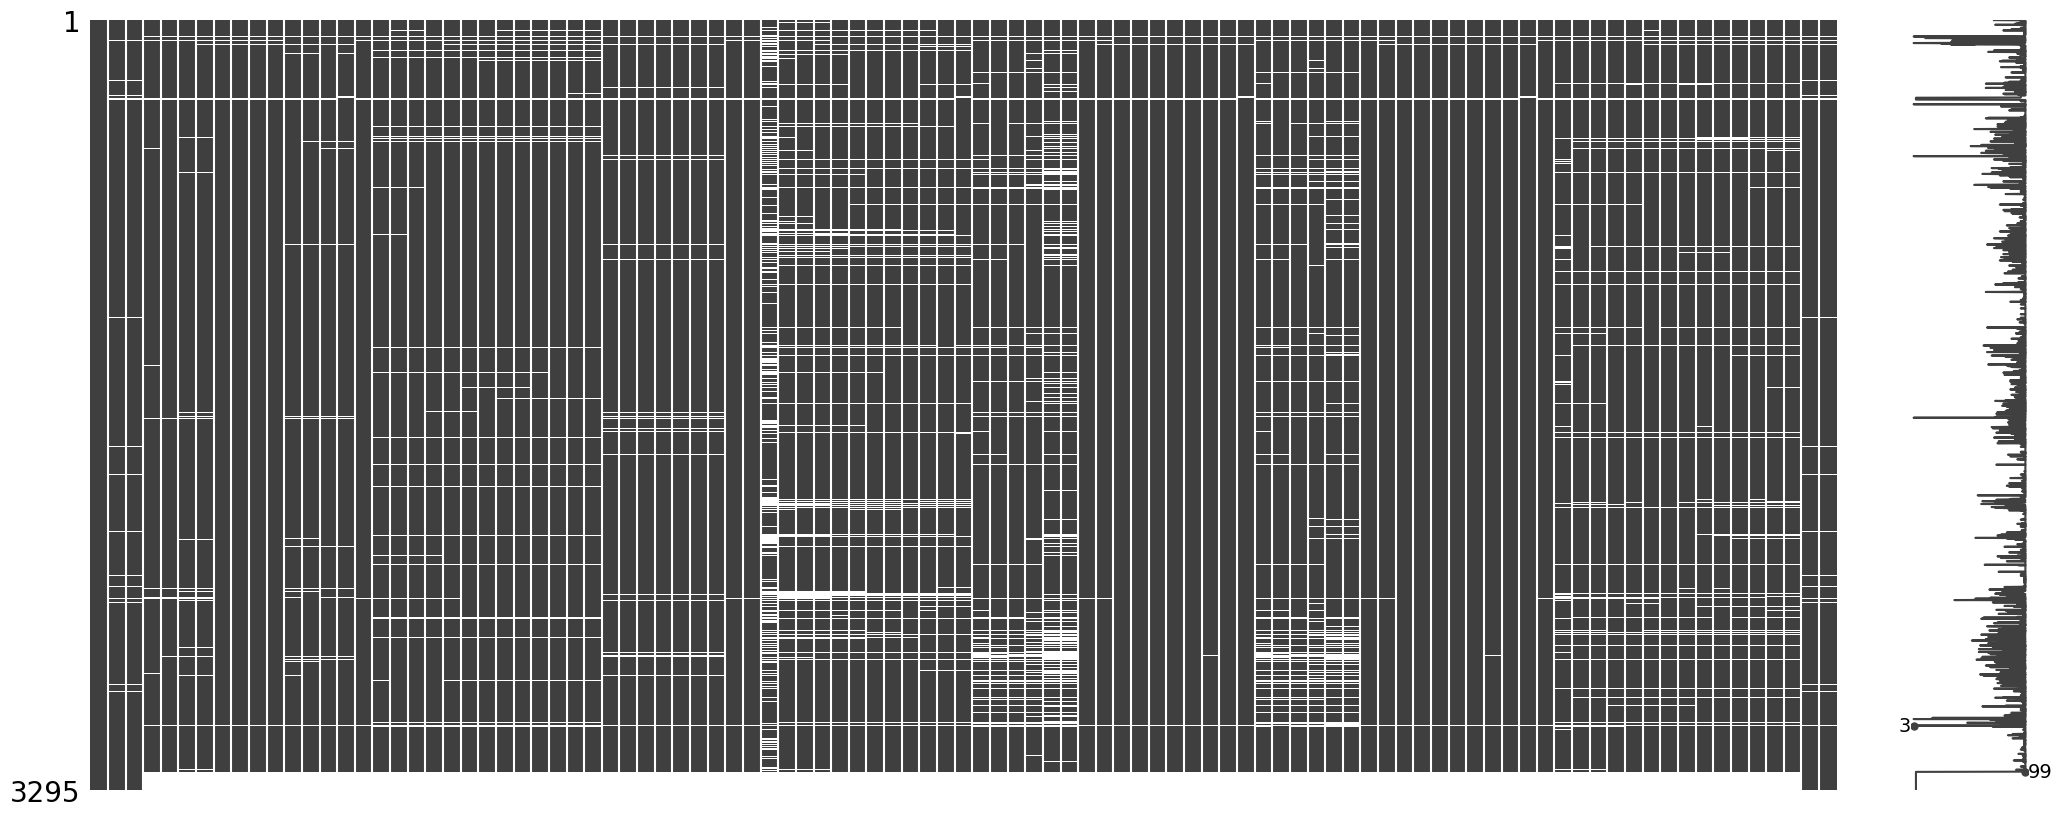

In [5]:
import missingno as msno
msno.matrix(df)
plt.show()

We notice that some rows have a lot of missing data. 

In [6]:
missing_fraction = df.isna().mean(axis=1)

rows_missing_data = df[missing_fraction > 0.90]

print('Total number of counties missing more than 90% of data is '+ str(len(rows_missing_data)))
display(rows_missing_data[['FIPS', 'State', 'County']])

Total number of counties missing more than 90% of data is 95


,FIPS,State,County
70,2010,AK,Aleutian Islands
98,2231,AK,Skagway-Yakutat-Angoon
332,9110,NaN,NaN
333,9120,NaN,NaN
334,9130,NaN,NaN
...,...,...,...
3290,72145,PR,Vega Baja
3291,72147,PR,Vieques
3292,72149,PR,Villalba
3293,72151,PR,Yabucoa


We note the lack of data for Puerto Rico.

In [7]:
missing_fraction_cols = df.isna().mean(axis=0)

worst_col = missing_fraction_cols.idxmax()

print("Column with most missing data:", worst_col)
print("Missing percent:", missing_fraction_cols[worst_col] * 100)
print("Missing count:", df[worst_col].isna().sum())

Column with most missing data: mental health providers raw value2013
Missing percent: 33.323216995447645
Missing count: 1098


We will still keep this variable as missing, since the percentage of missing values is not high.

In [8]:
df_new = df[missing_fraction <= 0.90]

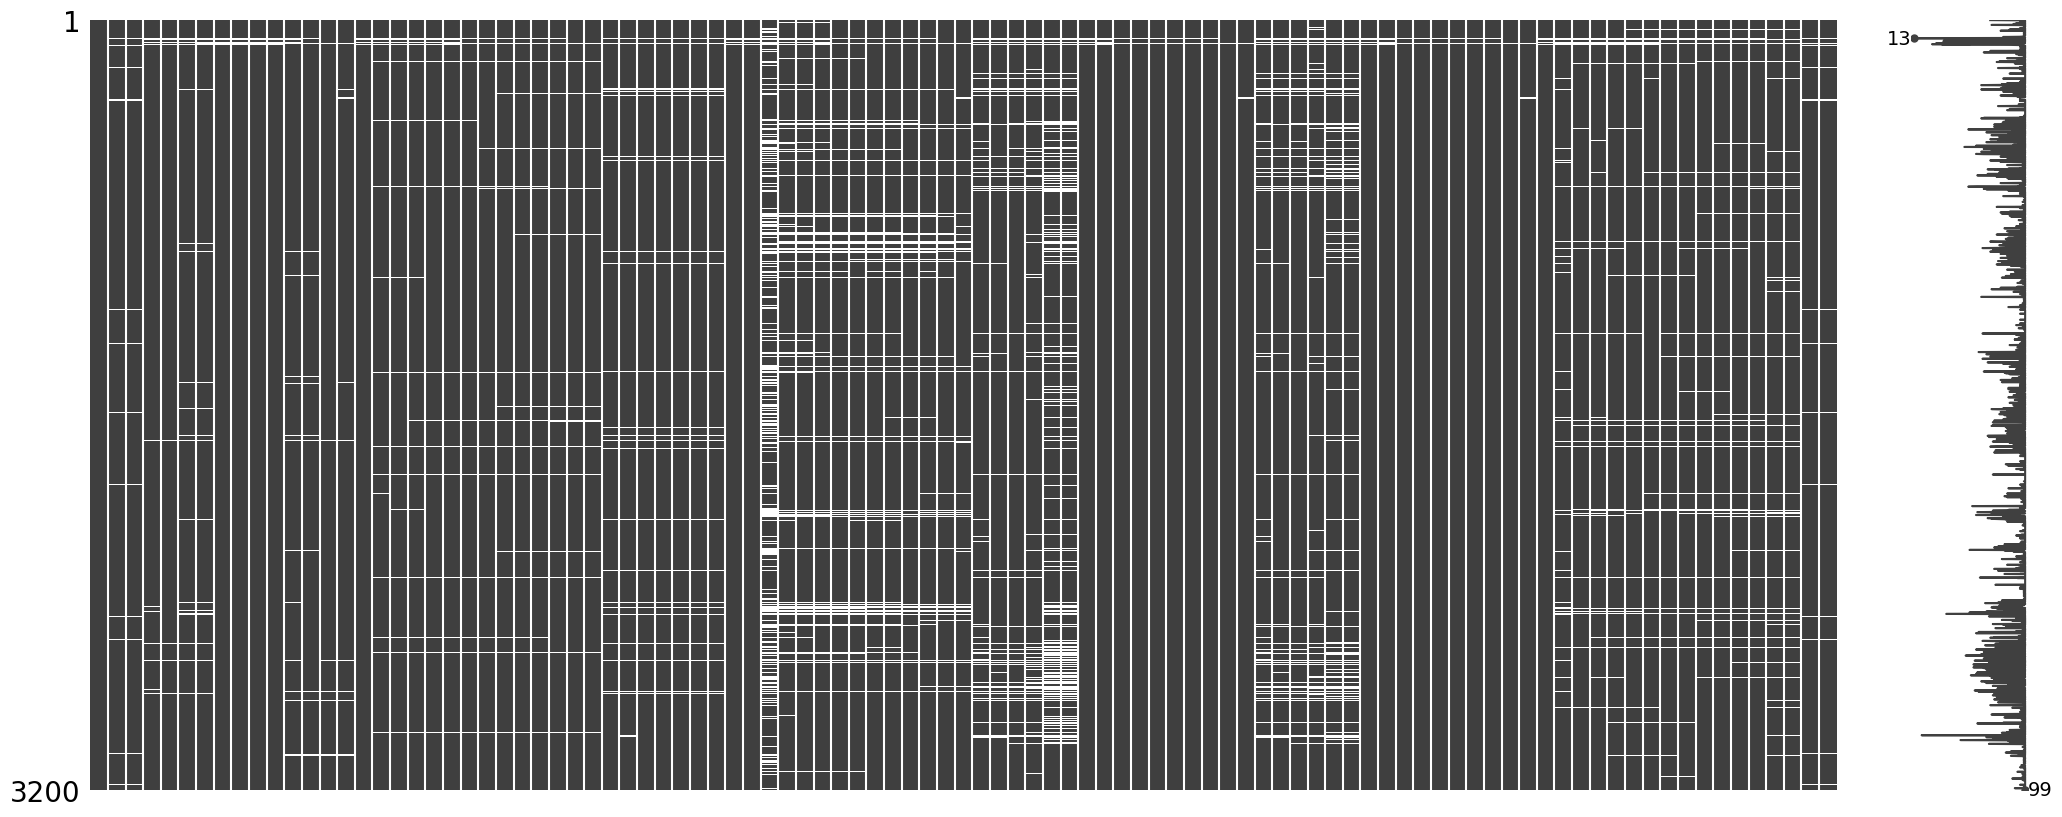

In [9]:
msno.matrix(df_new)
plt.show()

## Ranges and Impossible values


Now, let's carefully check the ranges and possible outliers for our variables.

In [10]:
poor_physical_health_cols = [
    "poor physical health days raw value2010",
    "poor physical health days raw value2011",
    "poor physical health days raw value2012",
    "poor physical health days raw value2013",
    "poor physical health days raw value2014",
    "poor physical health days raw value2015",
    "poor physical health days raw value2016",
    "poor physical health days raw value2017",
    "poor physical health days raw value2018",
    "poor physical health days raw value2019",
    "poor physical health days raw value2020",
    "poor physical health days raw value2021",
    "poor physical health days raw value2022",
    "poor physical health days raw value2023",
    "poor physical health days raw value2024",
    "poor physical health days raw value2025"
]

bad_physical = df_new[
    (df_new[poor_physical_health_cols].lt(0).any(axis=1)) |
    (df_new[poor_physical_health_cols].gt(30).any(axis=1))
]

print("Number of impossible Poor Physical Health Days values:", len(bad_physical))

if len(bad_physical) == 0:
    print("No impossible values found.")
else:
    display(bad_physical[["FIPS", "State", "County"] + poor_physical_health_cols])

Number of impossible Poor Physical Health Days values: 0
No impossible values found.


In [11]:
poor_mental_health_cols = [
    "poor mental health days raw value2010",
    "poor mental health days raw value2011",
    "poor mental health days raw value2012",
    "poor mental health days raw value2013",
    "poor mental health days raw value2014",
    "poor mental health days raw value2015",
    "poor mental health days raw value2016",
    "poor mental health days raw value2017",
    "poor mental health days raw value2018",
    "poor mental health days raw value2019",
    "poor mental health days raw value2020",
    "poor mental health days raw value2021",
    "poor mental health days raw value2022",
    "poor mental health days raw value2023",
    "poor mental health days raw value2024",
    "poor mental health days raw value2025"
]

bad_mental = df_new[
    (df_new[poor_mental_health_cols].lt(0).any(axis=1)) |
    (df_new[poor_mental_health_cols].gt(30).any(axis=1))
]

print("Number of impossible Poor Mental Health Days values:", len(bad_mental))

if len(bad_mental) == 0:
    print("No impossible values found.")
else:
    display(bad_mental[["FIPS", "State", "County"] + poor_mental_health_cols])

Number of impossible Poor Mental Health Days values: 0
No impossible values found.


In [12]:
exercise_access_cols = [
    "access to exercise opportunities raw value2014",
    "access to exercise opportunities raw value2015",
    "access to exercise opportunities raw value2016",
    "access to exercise opportunities raw value2017",
    "access to exercise opportunities raw value2018",
    "access to exercise opportunities raw value2019",
    "access to exercise opportunities raw value2020",
    "access to exercise opportunities raw value2021",
    "access to exercise opportunities raw value2022",
    "access to exercise opportunities raw value2023",
    "access to exercise opportunities raw value2024",
    "access to exercise opportunities raw value2025"
]

bad_exercise = df_new[
    (df_new[exercise_access_cols].lt(0).any(axis=1)) |
    (df_new[exercise_access_cols].gt(1).any(axis=1))
]

print("Number of impossible Access to Exercise Opportunities values:", len(bad_exercise))

if len(bad_exercise) == 0:
    print("No impossible values found.")
else:
    display(bad_exercise[["FIPS", "State", "County"] + exercise_access_cols])

Number of impossible Access to Exercise Opportunities values: 0
No impossible values found.


In [13]:
primary_care_cols = [
    "primary care physicians raw value2011",
    "primary care physicians raw value2012",
    "primary care physicians raw value2013",
    "primary care physicians raw value2014",
    "primary care physicians raw value2015",
    "primary care physicians raw value2016",
    "primary care physicians raw value2017",
    "primary care physicians raw value2018",
    "primary care physicians raw value2019",
    "primary care physicians raw value2020",
    "primary care physicians raw value2021",
    "primary care physicians raw value2022",
    "primary care physicians raw value2023",
    "primary care physicians raw value2024",
    "primary care physicians raw value2025"
]

bad_primary = df_new[
    df_new[primary_care_cols].lt(0).any(axis=1)
]

print("Number of impossible Primary Care Physicians values:", len(bad_primary))

if len(bad_primary) == 0:
    print("No impossible values found.")
else:
    display(bad_primary[["FIPS", "State", "County"] + primary_care_cols])

Number of impossible Primary Care Physicians values: 0
No impossible values found.


In [14]:
mental_health_provider_cols = [
    "mental health providers raw value2011",
    "mental health providers raw value2012",
    "mental health providers raw value2013",
    "mental health providers raw value2015",
    "mental health providers raw value2016",
    "mental health providers raw value2017",
    "mental health providers raw value2018",
    "mental health providers raw value2019",
    "mental health providers raw value2020",
    "mental health providers raw value2021",
    "mental health providers raw value2022",
    "mental health providers raw value2023",
    "mental health providers raw value2024",
    "mental health providers raw value2025"
]

bad_mental_providers = df_new[
    df_new[mental_health_provider_cols].lt(0).any(axis=1)
]

print("Number of impossible Mental Health Providers values:", len(bad_mental_providers))

if len(bad_mental_providers) == 0:
    print("No impossible values found.")
else:
    display(bad_mental_providers[["FIPS", "State", "County"] + mental_health_provider_cols])

Number of impossible Mental Health Providers values: 0
No impossible values found.


In [15]:
dentists_cols = [
    "dentists raw value2012",
    "dentists raw value2013",
    "dentists raw value2014",
    "dentists raw value2015",
    "dentists raw value2016",
    "dentists raw value2017",
    "dentists raw value2018",
    "dentists raw value2019",
    "dentists raw value2020",
    "dentists raw value2021",
    "dentists raw value2022",
    "dentists raw value2023",
    "dentists raw value2024",
    "dentists raw value2025"
]

bad_dentists = df_new[
    df_new[dentists_cols].lt(0).any(axis=1)
]

print("Number of impossible Dentists values:", len(bad_dentists))

if len(bad_dentists) == 0:
    print("No impossible values found.")
else:
    display(bad_dentists[["FIPS", "State", "County"] + dentists_cols])

Number of impossible Dentists values: 0
No impossible values found.


In [16]:
life_expectancy_cols = [
    "life expectancy raw value2019",
    "life expectancy raw value2020",
    "life expectancy raw value2021",
    "life expectancy raw value2022",
    "life expectancy raw value2023",
    "life expectancy raw value2024",
    "life expectancy raw value2025"
]

bad_life = df_new[
    (df_new[life_expectancy_cols].lt(0).any(axis=1)) |
    (df_new[life_expectancy_cols].gt(120).any(axis=1))
]

print("Number of impossible Life Expectancy values:", len(bad_life))

if len(bad_life) == 0:
    print("No impossible values found.")
else:
    display(bad_life[["FIPS", "State", "County"] + life_expectancy_cols])

Number of impossible Life Expectancy values: 0
No impossible values found.


## Duplicates

In [17]:
dup_rows = df_new.duplicated(keep = False)
print('Duplicate rows:', dup_rows.sum())

Duplicate rows: 0


## Profiling After Cleanup

In [18]:
display(df_new[poor_physical_health_cols].describe().T)
display(df_new[poor_mental_health_cols].describe().T)
display(df_new[exercise_access_cols].describe().T)
display(df_new[primary_care_cols].describe().T)
display(df_new[mental_health_provider_cols].describe().T)
display(df_new[dentists_cols].describe().T)
display(df_new[life_expectancy_cols].describe().T)

,count,mean,std,min,25%,50%,75%,max
poor physical health days raw value2010,2954.0,3.780142,1.116734,0.670000,3.040000,3.630000,4.360000,10.390000
poor physical health days raw value2011,2991.0,3.788131,1.099481,0.600000,3.100000,3.700000,4.300000,10.400000
poor physical health days raw value2012,3007.0,3.783705,1.104130,0.600000,3.100000,3.600000,4.400000,11.200000
poor physical health days raw value2013,2946.0,3.738934,1.042988,0.600000,3.000000,3.600000,4.300000,8.500000
poor physical health days raw value2014,2857.0,3.817711,1.137849,1.100000,3.000000,3.700000,4.400000,10.000000
poor physical health days raw value2015,2857.0,3.817711,1.137849,1.100000,3.000000,3.700000,4.400000,10.000000
poor physical health days raw value2016,3189.0,3.807013,0.737708,2.200000,3.300000,3.700000,4.300000,6.500000
poor physical health days raw value2017,3184.0,3.910091,0.723998,2.164197,3.379784,3.843831,4.403101,6.482353
poor physical health days raw value2018,3191.0,3.919868,0.712096,2.323511,3.393424,3.869127,4.408939,7.230990
poor physical health days raw value2019,3191.0,3.919868,0.712096,2.323511,3.393424,3.869127,4.408939,7.230990


,count,mean,std,min,25%,50%,75%,max
poor mental health days raw value2010,2955.0,3.449015,1.021515,0.440000,2.790000,3.350000,3.980000,8.300000
poor mental health days raw value2011,2994.0,3.470708,1.014255,0.600000,2.800000,3.400000,4.000000,9.600000
poor mental health days raw value2012,3006.0,3.484797,1.035190,0.700000,2.800000,3.400000,4.000000,9.600000
poor mental health days raw value2013,2911.0,3.424012,0.974720,0.400000,2.800000,3.400000,4.000000,7.500000
poor mental health days raw value2014,2639.0,3.560061,1.023609,1.000000,2.900000,3.500000,4.100000,10.100000
poor mental health days raw value2015,2639.0,3.560061,1.023609,1.000000,2.900000,3.500000,4.100000,10.100000
poor mental health days raw value2016,3189.0,3.674021,0.614403,2.100000,3.200000,3.700000,4.100000,5.600000
poor mental health days raw value2017,3184.0,3.779208,0.569315,2.276255,3.374788,3.765859,4.192556,5.775344
poor mental health days raw value2018,3191.0,3.932034,0.612485,2.439654,3.493647,3.934731,4.348770,5.964156
poor mental health days raw value2019,3191.0,3.932034,0.612485,2.439654,3.493647,3.934731,4.348770,5.964156


,count,mean,std,min,25%,50%,75%,max
access to exercise opportunities raw value2014,3167.0,0.527265,0.244792,0.0,0.351654,0.541327,0.708450,1.0
access to exercise opportunities raw value2015,3178.0,0.627874,0.229368,0.0,0.480941,0.657458,0.794968,1.0
access to exercise opportunities raw value2016,3117.0,0.596336,0.243191,0.0,0.436535,0.626445,0.777243,1.0
access to exercise opportunities raw value2017,3112.0,0.596482,0.242798,0.0,0.436681,0.626251,0.777155,1.0
access to exercise opportunities raw value2018,3186.0,0.632879,0.231411,0.0,0.495471,0.666307,0.807081,1.0
access to exercise opportunities raw value2019,3186.0,0.632048,0.230469,0.0,0.492815,0.667874,0.803117,1.0
access to exercise opportunities raw value2020,3186.0,0.631147,0.233384,0.0,0.487472,0.662595,0.804290,1.0
access to exercise opportunities raw value2021,3186.0,0.631147,0.233384,0.0,0.487472,0.662595,0.804290,1.0
access to exercise opportunities raw value2022,3116.0,0.554837,0.238198,0.0,0.399910,0.569222,0.729431,1.0
access to exercise opportunities raw value2023,3130.0,0.611700,0.237280,0.0,0.467214,0.637526,0.792323,1.0


,count,mean,std,min,25%,50%,75%,max
primary care physicians raw value2011,3190.0,0.000574,0.000442,0.0,0.000296,0.000507,0.000754,0.006319
primary care physicians raw value2012,3013.0,0.000608,0.000432,0.0,0.000332,0.000529,0.000773,0.006319
primary care physicians raw value2013,3067.0,0.000555,0.000348,0.0,0.000335,0.000509,0.000716,0.004589
primary care physicians raw value2014,3050.0,0.000556,0.000337,0.0,0.000344,0.000507,0.000722,0.005083
primary care physicians raw value2015,3051.0,0.000557,0.000343,0.0,0.000336,0.000503,0.000727,0.004760
primary care physicians raw value2016,3053.0,0.000561,0.000346,0.0,0.000335,0.000508,0.000729,0.004692
primary care physicians raw value2017,3053.0,0.000555,0.000347,0.0,0.000331,0.000499,0.000723,0.004667
primary care physicians raw value2018,3058.0,0.000552,0.000350,0.0,0.000323,0.000496,0.000721,0.004527
primary care physicians raw value2019,3057.0,0.000549,0.000352,0.0,0.000324,0.000493,0.000719,0.004772
primary care physicians raw value2020,3045.0,0.000549,0.000352,0.0,0.000321,0.000489,0.000717,0.005144


,count,mean,std,min,25%,50%,75%,max
mental health providers raw value2011,3191.0,0.000181,0.000606,0.0,0.000000,0.000061,0.000207,0.026180
mental health providers raw value2012,3191.0,0.000181,0.000606,0.0,0.000000,0.000061,0.000207,0.026180
mental health providers raw value2013,2197.0,0.000264,0.000374,0.0,0.000080,0.000166,0.000331,0.011111
mental health providers raw value2015,2855.0,0.001163,0.001253,0.0,0.000353,0.000814,0.001541,0.014085
mental health providers raw value2016,2880.0,0.001236,0.001350,0.0,0.000375,0.000865,0.001640,0.013998
mental health providers raw value2017,2898.0,0.001327,0.001437,0.0,0.000400,0.000929,0.001766,0.015770
mental health providers raw value2018,2928.0,0.001417,0.001521,0.0,0.000427,0.000983,0.001903,0.017865
mental health providers raw value2019,2940.0,0.001516,0.001608,0.0,0.000453,0.001051,0.002049,0.020027
mental health providers raw value2020,2962.0,0.001626,0.001731,0.0,0.000494,0.001142,0.002194,0.022123
mental health providers raw value2021,2971.0,0.001706,0.001824,0.0,0.000528,0.001192,0.002267,0.024080


,count,mean,std,min,25%,50%,75%,max
dentists raw value2012,3190.0,0.000334,0.000220,0.0,0.000190,0.000307,0.000453,0.002674
dentists raw value2013,3104.0,0.000388,0.000244,0.0,0.000225,0.000353,0.000517,0.003232
dentists raw value2014,3109.0,0.000409,0.000260,0.0,0.000236,0.000370,0.000545,0.003375
dentists raw value2015,3108.0,0.000420,0.000267,0.0,0.000243,0.000380,0.000557,0.003582
dentists raw value2016,3112.0,0.000429,0.000279,0.0,0.000249,0.000390,0.000566,0.004393
dentists raw value2017,3106.0,0.000437,0.000288,0.0,0.000254,0.000394,0.000578,0.005278
dentists raw value2018,3109.0,0.000448,0.000301,0.0,0.000255,0.000403,0.000598,0.006043
dentists raw value2019,3107.0,0.000457,0.000313,0.0,0.000262,0.000412,0.000611,0.007251
dentists raw value2020,3104.0,0.000462,0.000315,0.0,0.000266,0.000419,0.000616,0.007113
dentists raw value2021,3103.0,0.000473,0.000325,0.0,0.000269,0.000428,0.000631,0.007060


,count,mean,std,min,25%,50%,75%,max
life expectancy raw value2019,3123.0,77.463026,2.988052,62.441612,75.517778,77.564608,79.304587,97.965235
life expectancy raw value2020,3119.0,77.483841,3.025771,61.625629,75.568594,77.508223,79.367145,104.740145
life expectancy raw value2021,3123.0,77.530786,3.116198,64.412891,75.563356,77.564354,79.448636,113.462137
life expectancy raw value2022,3122.0,76.914543,3.250430,61.055823,74.943559,76.956685,78.939352,112.503856
life expectancy raw value2023,3122.0,76.914543,3.250430,61.055823,74.943559,76.956685,78.939352,112.503856
life expectancy raw value2024,3120.0,75.777897,3.420068,55.918958,73.608159,75.881642,78.018878,98.902938
life expectancy raw value2025,3118.0,75.168981,3.612265,53.980813,72.818940,75.307683,77.554834,94.218993


## Correlation Between Variables

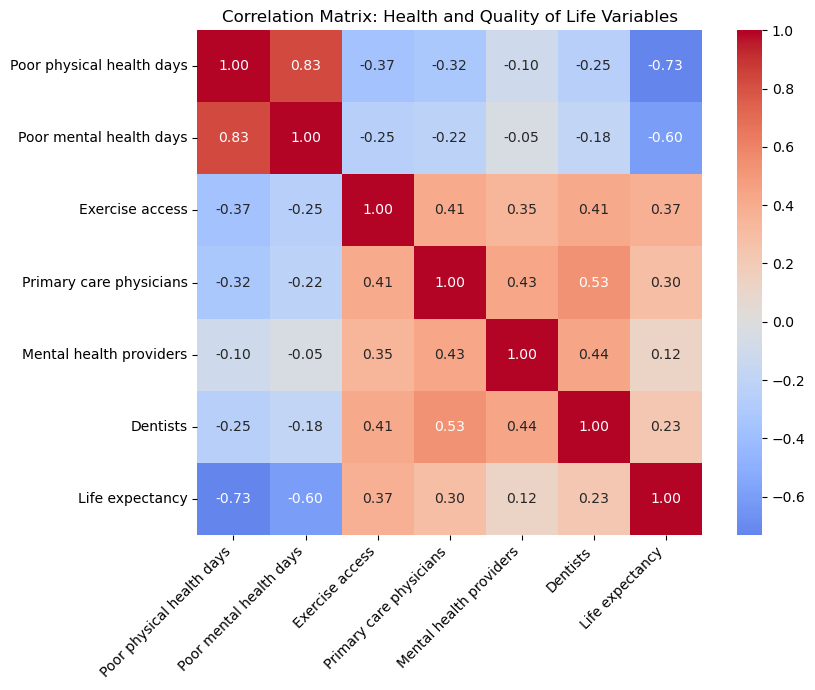

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

plot_cols = [ #here we pick the latest data available for each category
    "poor physical health days raw value2025",
    "poor mental health days raw value2025",
    "access to exercise opportunities raw value2025",
    "primary care physicians raw value2025",
    "mental health providers raw value2025",
    "dentists raw value2025",
    "life expectancy raw value2025"
]

short_names = {
    "poor physical health days raw value2025": "Poor physical health days",
    "poor mental health days raw value2025": "Poor mental health days",
    "access to exercise opportunities raw value2025": "Exercise access",
    "primary care physicians raw value2025": "Primary care physicians",
    "mental health providers raw value2025": "Mental health providers",
    "dentists raw value2025": "Dentists",
    "life expectancy raw value2025": "Life expectancy"
}

corr = df_new[plot_cols].corr()
corr = corr.rename(index=short_names, columns=short_names)

fig, ax = plt.subplots(figsize=(9, 7))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    ax=ax,
    square=True
)

ax.set_title("Correlation Matrix: Health and Quality of Life Variables")

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

The strongest relationship is between Poor Physical Health Days and Poor Mental Health Days (0.83). This shouldn't be surprising, as feeling physically down and mentally down are closely related; however, seeing such a high number is still interesting.

Another important observation is that Life Expectancy is strongly negatively correlated with Poor Physical Health Days (-0.73) and Poor Mental Health Days (-0.60).

One interesting observation is the considerable correlation (0.53) between Dentists and Primary Care Physicians (or Mental Health Providers (0.44)). This may suggest that having better access to one type of healthcare resource is often associated with better access to other healthcare resources.

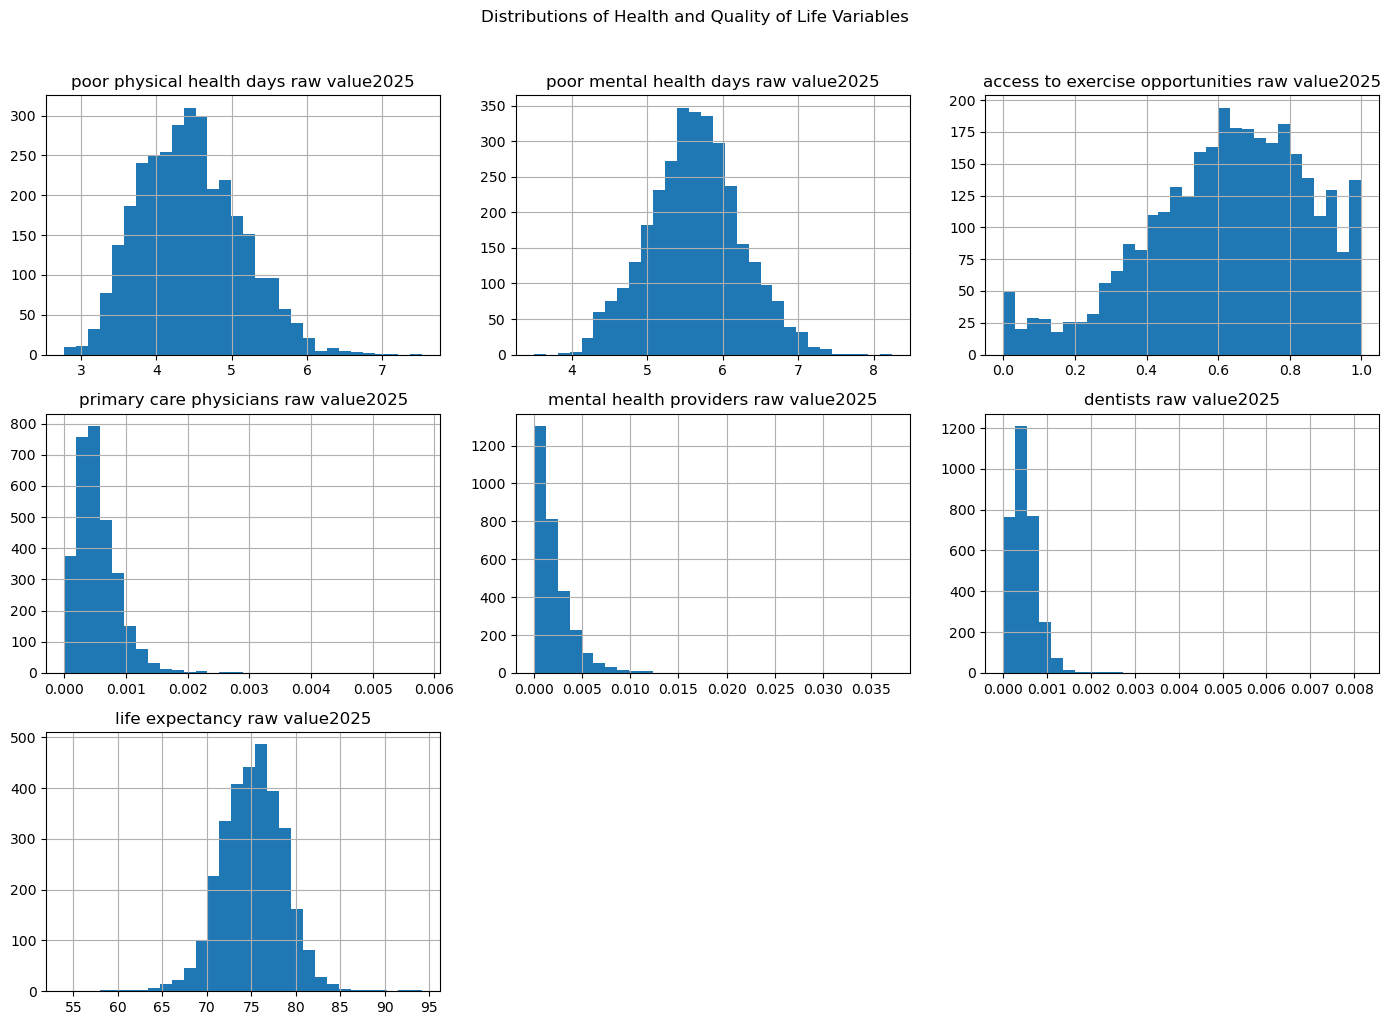

In [20]:
latest_cols = [
    "poor physical health days raw value2025",
    "poor mental health days raw value2025",
    "access to exercise opportunities raw value2025",
    "primary care physicians raw value2025",
    "mental health providers raw value2025",
    "dentists raw value2025",
    "life expectancy raw value2025"
]

df_new[latest_cols].hist(figsize=(14, 10), bins=30)

plt.suptitle("Distributions of Health and Quality of Life Variables", y=1.02)
plt.tight_layout()
plt.show()

## Visualization of Data
This section will visualize certain variables and their changes over the years based on the location.

In [21]:
import pandas as pd
import numpy as np
import plotly.figure_factory as ff

def exercise_access(state_name):
    exercise_cols = [
        "access to exercise opportunities raw value2014",
        "access to exercise opportunities raw value2015",
        "access to exercise opportunities raw value2016",
        "access to exercise opportunities raw value2017",
        "access to exercise opportunities raw value2018",
        "access to exercise opportunities raw value2019",
        "access to exercise opportunities raw value2020",
        "access to exercise opportunities raw value2021",
        "access to exercise opportunities raw value2022",
        "access to exercise opportunities raw value2023",
        "access to exercise opportunities raw value2024",
        "access to exercise opportunities raw value2025"
    ]

    df_state = df_new[df_new["State"].str.lower() == state_name.lower()].copy()

    df_long = df_state.melt(
        id_vars=["FIPS", "State", "County", "Latitude", "Longitude"],
        value_vars=exercise_cols,
        var_name="variable_year",
        value_name="exercise_access"
    )

    df_long["year"] = df_long["variable_year"].str.extract(r"(\d{4})").astype(int)

    # Convert from decimal to percent
    df_long["exercise_access_percent"] = df_long["exercise_access"] * 100

    df_long = df_long.dropna(
        subset=["Latitude", "Longitude", "exercise_access_percent"]
    )

    if len(df_long) == 0:
        print(f"No usable data found for {state_name}.")
        return

    fig = ff.create_hexbin_mapbox(
        data_frame=df_long,
        lat="Latitude",
        lon="Longitude",
        color="exercise_access_percent",
        agg_func=np.mean,
        animation_frame="year",
        nx_hexagon=10,
        min_count=1,
        opacity=0.7,

        # Red = low, yellow = middle, green = high
        color_continuous_scale=[
            [0.0, "red"],
            [0.5, "yellow"],
            [1.0, "green"]
        ],

        # Fixed percent scale from 0 to 100
        range_color=[0, 100],

        labels={
            "color": "Exercise access (%)",
            "frame": "Year"
        },
        show_original_data=True
    )

    fig.update_layout(
        title=f"Access to Exercise Opportunities (%) in {state_name.title()}, 2014–2025",
        mapbox_style="open-street-map",
        margin=dict(b=0, t=40, l=0, r=0)
    )

    fig.show()

In [22]:
#You can use this function to see changes in Access to Exercise Opportunities by entering the abbreviation of the state.
exercise_access("MI")

We have tried plugging in a couple of different states (e.g., one can try IL or MI) and observed that there is a considerable decline in exercise opportunities from 2021 to 2022. Let's check that:

In [23]:
df_side_quest = df_new.copy()

print("Average in 2021:", df_side_quest["access to exercise opportunities raw value2021"].mean())
print("Average in 2022:", df_side_quest["access to exercise opportunities raw value2022"].mean())

df_side_quest["exercise_change_2021_to_2022"] = (df_side_quest["access to exercise opportunities raw value2022"]- df_side_quest["access to exercise opportunities raw value2021"])
print("Number of counties that decreased:", len(df_side_quest[df_side_quest["exercise_change_2021_to_2022"] < 0]))



Average in 2021: 0.6311468135539863
Average in 2022: 0.5548373057605904
Number of counties that decreased: 2771


That is almost 87% of the counties that we had. Our best guess is that this change is related to post-COVID regulations.

In [24]:
import plotly.express as px

def life_expectancy_trend(state_name):
    life_cols = [
        "life expectancy raw value2019",
        "life expectancy raw value2020",
        "life expectancy raw value2021",
        "life expectancy raw value2022",
        "life expectancy raw value2023",
        "life expectancy raw value2024",
        "life expectancy raw value2025"
    ]

    df_state = df_new[df_new["State"].str.lower() == state_name.lower()].copy()

    df_long = df_state.melt(
        id_vars=["FIPS", "State", "County"],
        value_vars=life_cols,
        var_name="variable_year",
        value_name="life_expectancy"
    )

    df_long["year"] = df_long["variable_year"].str.extract(r"(\d{4})").astype(int)

    state_trend = (
        df_long
        .groupby("year", as_index=False)["life_expectancy"]
        .mean()
    )

    fig = px.line(
        state_trend,
        x="year",
        y="life_expectancy",
        markers=True,
        title=f"Average Life Expectancy in {state_name.title()}, 2019–2025",
        labels={
            "year": "Year",
            "life_expectancy": "Average Life Expectancy"
        }
    )

    fig.update_yaxes(range=[60, 90])

    fig.show()

In [25]:
#You can use this function to see changes in Life Expectancy by entering the abbreviation of the state.
life_expectancy_trend("MI")

In [26]:
import pandas as pd
import plotly.express as px

def poor_mental_health_box(state_name):
    mental_cols = [
        "poor mental health days raw value2010",
        "poor mental health days raw value2011",
        "poor mental health days raw value2012",
        "poor mental health days raw value2013",
        "poor mental health days raw value2014",
        "poor mental health days raw value2015",
        "poor mental health days raw value2016",
        "poor mental health days raw value2017",
        "poor mental health days raw value2018",
        "poor mental health days raw value2019",
        "poor mental health days raw value2020",
        "poor mental health days raw value2021",
        "poor mental health days raw value2022",
        "poor mental health days raw value2023",
        "poor mental health days raw value2024",
        "poor mental health days raw value2025"
    ]

    df_state = df_new[df_new["State"].str.lower() == state_name.lower()].copy()

    df_long = df_state.melt(
        id_vars=["FIPS", "State", "County"],
        value_vars=mental_cols,
        var_name="variable_year",
        value_name="poor_mental_health_days"
    )

    df_long["year"] = df_long["variable_year"].str.extract(r"(\d{4})").astype(int)

    df_long = df_long.dropna(subset=["year", "poor_mental_health_days"])

    if len(df_long) == 0:
        print(f"No usable poor mental health days data found for {state_name}.")
        return

    fig = px.box(
        df_long,
        x="year",
        y="poor_mental_health_days",
        points="all",
        hover_name="County",
        title=f"Distribution of Poor Mental Health Days in {state_name.title()}",
        labels={
            "year": "Year",
            "poor_mental_health_days": "Poor mental health days"
        }
    )

    fig.show()

In [27]:
#You can use this function to see changes in Poor Mental Health Days by entering the abbreviation of the state.
poor_mental_health_box("MI")

Again, if one tries plugging in a couple of different states (e.g., IL or MI), they can observe interesting jumps in the number of Poor Mental Health Days during COVID (and maybe during major political changes).

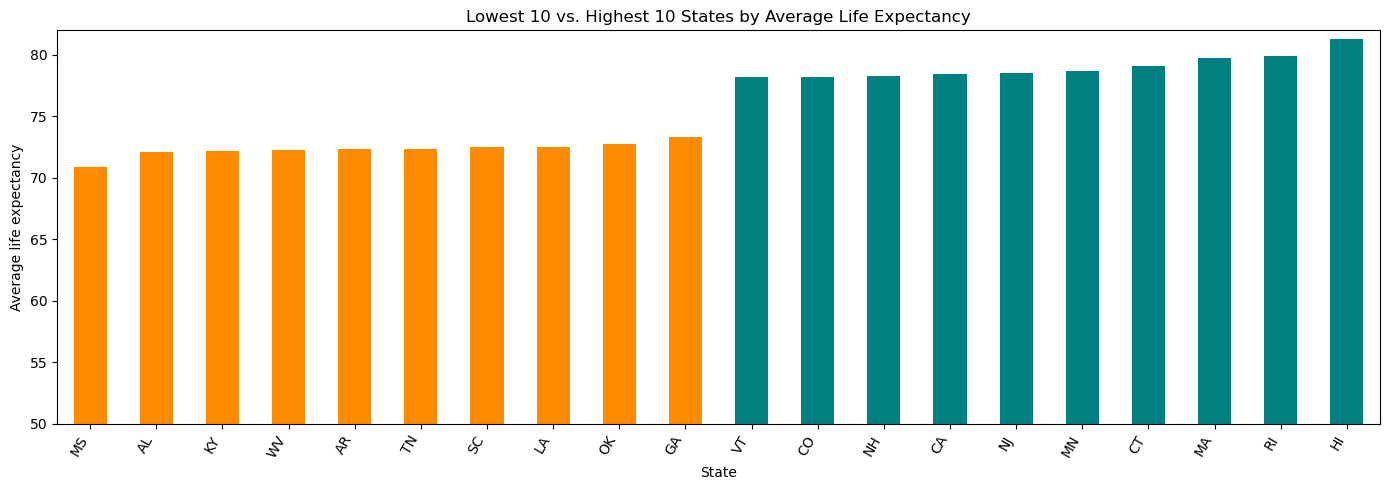

In [28]:
state_life_exp = (
    df_new
    .groupby("State")["life expectancy raw value2025"]
    .mean()
    .dropna()
    .sort_values()
)

state_life_exp_extremes = pd.concat([
    state_life_exp.head(10),
    state_life_exp.tail(10)
])

fig, ax = plt.subplots(figsize=(14, 5))

state_life_exp_extremes.plot(
    kind="bar",
    ax=ax,
    color=(["darkorange"] * 10 + ["teal"] * 10)
)

ax.set_title("Lowest 10 vs. Highest 10 States by Average Life Expectancy")
ax.set_ylabel("Average life expectancy")
ax.set_xlabel("State")

ax.set_ylim(50, 82)

plt.xticks(rotation=60, ha="right")
plt.tight_layout()
plt.show()

# Scoring using PCA

In [29]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import pandas as pd

pca_cols = [
    "FIPS",
    "State",
    "County",
    "poor physical health days raw value2025",
    "poor mental health days raw value2025",
    "access to exercise opportunities raw value2025",
    "primary care physicians raw value2025",
    "mental health providers raw value2025",
    "dentists raw value2025",
    "life expectancy raw value2025"
]

pca_df = df_new[pca_cols].copy()

score_cols = pca_cols[3:]

# we fill missing values with median
for col in score_cols:
    pca_df[col] = pca_df[col].fillna(pca_df[col].median())

# we reverse variables where bigger is worse, so bigger is always better
pca_df["poor physical health days raw value2025"] = -pca_df["poor physical health days raw value2025"]
pca_df["poor mental health days raw value2025"] = -pca_df["poor mental health days raw value2025"]

scaler = StandardScaler()
pca_scaled = scaler.fit_transform(pca_df[score_cols])

pca = PCA(n_components=2)
pca_scores = pca.fit_transform(pca_scaled)

pca.components_, pca.explained_variance_ratio_

(array([[ 0.46532251,  0.40871692,  0.36538895,  0.35983884,  0.24634396,
          0.33630584,  0.42384597],
        [-0.36444371, -0.41806854,  0.20689861,  0.36169251,  0.50641393,
          0.41238842, -0.30372963]]),
 array([0.44813327, 0.23099464]))

This shows that PC1 accounts for 44.8% of the variance of our variables. Let's check it more carefully:

In [30]:
loadings = pd.DataFrame(
    pca.components_.T,
    columns=["PC1", "PC2"],
    index=score_cols
)

display(loadings)

,PC1,PC2
poor physical health days raw value2025,0.465323,-0.364444
poor mental health days raw value2025,0.408717,-0.418069
access to exercise opportunities raw value2025,0.365389,0.206899
primary care physicians raw value2025,0.359839,0.361693
mental health providers raw value2025,0.246344,0.506414
dentists raw value2025,0.336306,0.412388
life expectancy raw value2025,0.423846,-0.303730


PC1 seems to capture the overall Health and Quality of Life score well. Since we reversed the poor health variables, higher PC1 means fewer poor physical and mental health days, higher life expectancy, better access to exercise, and more healthcare providers.

PC2 seems to focus more on healthcare provider availability, especially Mental Health Providers, Dentists, and Primary Care Physicians.

In [31]:
pca_df["PC1"] = pca_scores[:, 0]

pca_df["Health and Quality of Life Score"] = (
    100 * (pca_df["PC1"] - pca_df["PC1"].min()) /
    (pca_df["PC1"].max() - pca_df["PC1"].min())
)

df_scores = pca_df.sort_values(by="Health and Quality of Life Score", ascending=False)[["FIPS", "State", "County", "Health and Quality of Life Score"]]

display(df_scores)
df_scores.to_csv("Health and Quality of Life Score by County.csv", index=False)

,FIPS,State,County,Health and Quality of Life Score
2996,51610,VA,Falls Church,100.000000
442,13053,GA,Chattahoochee,88.878545
2350,42093,PA,Montour,84.148455
96,2220,AK,Sitka,83.419297
2012,37135,NC,Orange,76.792084
...,...,...,...,...
2485,46121,SD,Todd,4.846776
2719,48261,TX,Kenedy,4.662630
3094,54059,WV,Mingo,1.933003
3088,54047,WV,McDowell,0.963381


# Validation

Now our goal is to check if the counties with higher custom Health and Quality of Life Score have higher migration rates.

## Correlation between Health and Quality of Life Scores and Migration Rates
We have the migration data by county for the last three years. We want to use average migration rates (per 1000 people). We will examine domestic, international, and total migrations.

In [32]:
scores_df = pd.read_csv("Health and Quality of Life Score by County.csv")
migration_df = pd.read_csv("Migration Rates by County.csv")

migration_df["avg_net_domestic_migration_rate"] = migration_df[["RDOMESTICMIG2023", "RDOMESTICMIG2024", "RDOMESTICMIG2025"]].mean(axis=1)

migration_df["avg_net_international_migration_rate"] = migration_df[["RINTERNATIONALMIG2023", "RINTERNATIONALMIG2024", "RINTERNATIONALMIG2025"]].mean(axis=1)

migration_df["avg_net_total_migration_rate"] = migration_df[["RNETMIG2023", "RNETMIG2024", "RNETMIG2025"]].mean(axis=1)

validation_df = scores_df[["FIPS", "State", "County", "Health and Quality of Life Score"]].merge(
    migration_df[["FIPS", "avg_net_domestic_migration_rate","avg_net_international_migration_rate", "avg_net_total_migration_rate"]], on="FIPS", how="left")

validation_df = validation_df.dropna(subset=["Health and Quality of Life Score", "avg_net_international_migration_rate",  "avg_net_domestic_migration_rate","avg_net_total_migration_rate"])

display(validation_df.sample(5))

,FIPS,State,County,Health and Quality of Life Score,avg_net_domestic_migration_rate,avg_net_international_migration_rate,avg_net_total_migration_rate
238,33013,NH,Merrimack,52.640911,5.405903,1.096647,6.502550
1444,46111,SD,Sanborn,37.543667,-3.896919,2.230384,-1.666535
820,23003,ME,Aroostook,43.447169,3.206681,1.110610,4.317290
2743,48407,TX,San Jacinto,24.062333,12.742860,1.066925,13.809785
839,36015,NY,Chemung,43.196547,-1.416676,1.045232,-0.371444


In [33]:
pearson_corr = validation_df["Health and Quality of Life Score"].corr(
    validation_df["avg_net_domestic_migration_rate"],
    method="pearson"
)

spearman_corr = validation_df["Health and Quality of Life Score"].corr(
    validation_df["avg_net_domestic_migration_rate"],
    method="spearman"
)

print("Using Average Net Domestic Migration Rate, we got:")
print("Pearson correlation:", pearson_corr)
print("Spearman correlation:", spearman_corr)

pearson_corr = validation_df["Health and Quality of Life Score"].corr(
    validation_df["avg_net_international_migration_rate"],
    method="pearson"
)

spearman_corr = validation_df["Health and Quality of Life Score"].corr(
    validation_df["avg_net_international_migration_rate"],
    method="spearman"
)

print("Using Average Net International Migration Rate, we got:")
print("Pearson correlation:", pearson_corr)
print("Spearman correlation:", spearman_corr)

pearson_corr = validation_df["Health and Quality of Life Score"].corr(
    validation_df["avg_net_total_migration_rate"],
    method="pearson"
)

spearman_corr = validation_df["Health and Quality of Life Score"].corr(
    validation_df["avg_net_total_migration_rate"],
    method="spearman"
)

print("Using Average Net Total Migration Rate, we got:")
print("Pearson correlation:", pearson_corr)
print("Spearman correlation:", spearman_corr)

Using Average Net Domestic Migration Rate, we got:
Pearson correlation: -0.1356214084135354
Spearman correlation: -0.17688576884233367
Using Average Net International Migration Rate, we got:
Pearson correlation: 0.3352709075028032
Spearman correlation: 0.3977444630523047
Using Average Net Total Migration Rate, we got:
Pearson correlation: -0.020134006347560882
Spearman correlation: -0.05209553989683056


The Health and Quality of Life score shows a slight negative relation with domestic migration, but a clearer positive relation with international migration. Note that this category alone does not explain overall migration patterns, since the total migration correlation is almost zero. However, the connection with international migration is stronger than what we saw for domestic or total migration, which is an interesting point.

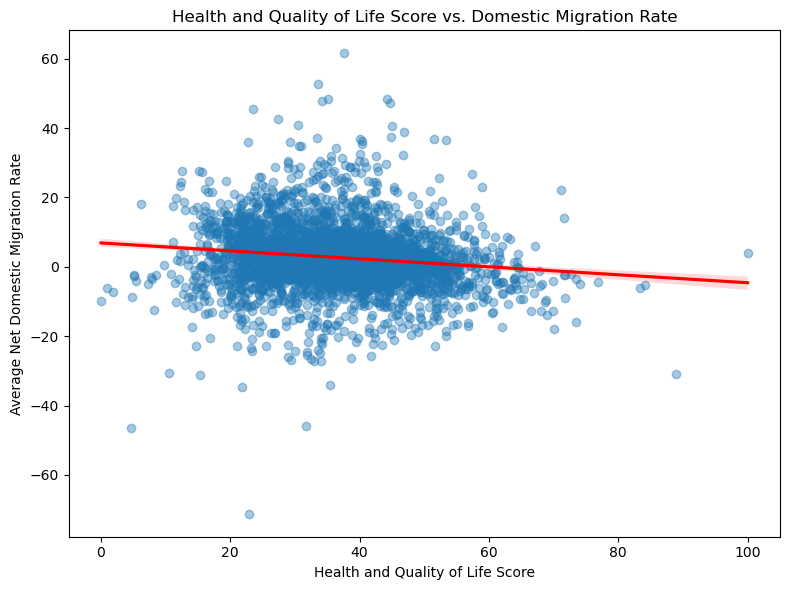

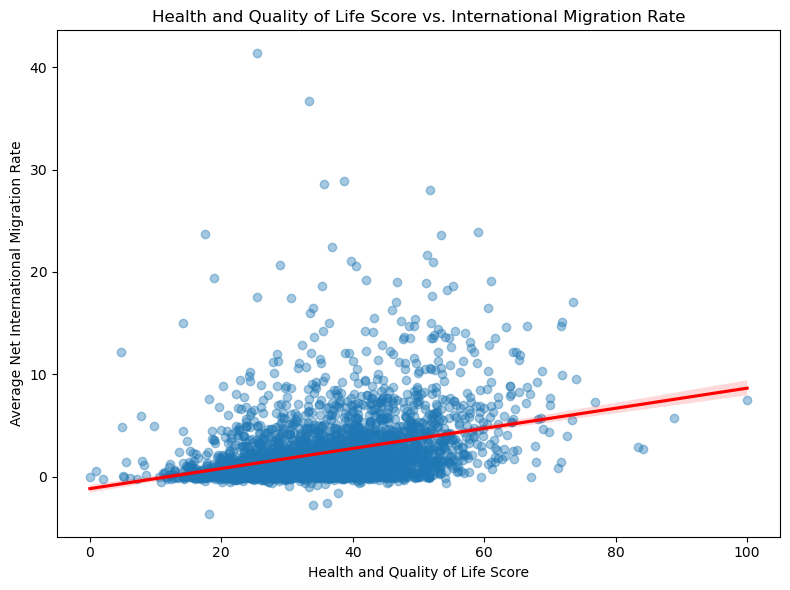

In [34]:

# for domestic migration
fig, ax = plt.subplots(figsize=(8, 6))

sns.regplot(
    data=validation_df,
    x="Health and Quality of Life Score",
    y="avg_net_domestic_migration_rate",
    scatter_kws={"alpha": 0.4},
    line_kws={"color": "red"},
    ax=ax
)

ax.set_title("Health and Quality of Life Score vs. Domestic Migration Rate")
ax.set_xlabel("Health and Quality of Life Score")
ax.set_ylabel("Average Net Domestic Migration Rate")

plt.tight_layout()
plt.show()


# for international migration
fig, ax = plt.subplots(figsize=(8, 6))

sns.regplot(
    data=validation_df,
    x="Health and Quality of Life Score",
    y="avg_net_international_migration_rate",
    scatter_kws={"alpha": 0.4},
    line_kws={"color": "red"},
    ax=ax
)

ax.set_title("Health and Quality of Life Score vs. International Migration Rate")
ax.set_xlabel("Health and Quality of Life Score")
ax.set_ylabel("Average Net International Migration Rate")

plt.tight_layout()
plt.show()